In [2]:
import tensorflow as tf
from tensorflow import keras


import os
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics
from PIL import Image
import pandas as pd

# discontinued import tensorflow_addons as tfa
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import load_model
# from tensorflow.keras.regularizers import l2
# from tensorflow.keras.layers import Dropout, Dense, Flatten

from sklearn.utils import resample
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from collections import Counter


# tf.config.list_physical_devices('GPU')

In [3]:
import os

base_dir = "../kaggle/input/"
if os.path.exists(base_dir):
    print("Dataset folder exists. Contents:", os.listdir(base_dir))
else:
    print("Dataset folder NOT found.")


Dataset folder NOT found.


In [4]:
import os
print(os.listdir("/kaggle/input/"))


['Dataset - train+val+test']


In [5]:
base_dir = '/kaggle/input/Dataset - train+val+test'
data = tf.keras.preprocessing.image_dataset_from_directory(base_dir)


Found 109309 files belonging to 3 classes.


In [6]:
print('Base directory --> ', os.listdir(base_dir))

Base directory -->  ['val', 'test', 'train']


In [7]:
# NOT EXCHANGED

train_dir = '/kaggle/input/Dataset - train+val+test/train'
print("Train Directory --> ", os.listdir(train_dir))

validation_dir = '/kaggle/input/Dataset - train+val+test/val'
print("Validation Directory --> ", os.listdir(validation_dir))

test_dir = '/kaggle/input/Dataset - train+val+test/test'
print("Test Directory --> ", os.listdir(test_dir))

Train Directory -->  ['DRUSEN', 'CNV', 'NORMAL', 'DME']
Validation Directory -->  ['DRUSEN', 'CNV', 'NORMAL', 'DME']
Test Directory -->  ['DRUSEN', 'CNV', 'NORMAL', 'DME']


In [8]:
# Load image paths and labels
image_paths = []
labels = []

for class_label in ['CNV', 'DRUSEN', 'DME', 'NORMAL']:
    class_dir = os.path.join(train_dir, class_label)
    for img_name in os.listdir(class_dir):
        image_paths.append(os.path.join(class_dir, img_name))
        labels.append(class_label)

# Convert to numpy arrays
image_paths = np.array(image_paths)
labels = np.array(labels)

# Check class distribution
print(Counter(labels))




Counter({'NORMAL': 35973, 'CNV': 26218, 'DME': 8118, 'DRUSEN': 6206})


In [9]:

# Find minimum class size
min_class_size = min(Counter(labels).values())

# Function to undersample
def undersample(image_paths, labels, target_size):
    undersampled_paths = []
    undersampled_labels = []

    for class_label in np.unique(labels):
        # Get indices of the current class
        class_indices = np.where(labels == class_label)[0]
        
        # Downsample to target size
        undersampled_indices = resample(class_indices, 
                                        replace=False, 
                                        n_samples=target_size, 
                                        random_state=42)
        
        undersampled_paths.extend(image_paths[undersampled_indices])
        undersampled_labels.extend(labels[undersampled_indices])

    return np.array(undersampled_paths), np.array(undersampled_labels)

# Undersample to the size of the smallest class
image_paths_resampled, labels_resampled = undersample(image_paths, labels, min_class_size)

# Check new class distribution
print(Counter(labels_resampled))

Counter({'CNV': 6206, 'DME': 6206, 'DRUSEN': 6206, 'NORMAL': 6206})


In [10]:
from tensorflow.keras.applications import InceptionV3
inc = InceptionV3(input_shape=(224,224,3),weights='imagenet',include_top=False)
for i in inc.layers:
    i.trainable = False
print(inc.summary())

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 111, 111, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 111, 111, 32)   │             96 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 111, 111, 32)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 109, 109, 32)   │          9,216 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 109, 109, 32)   │             96 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 109, 109, 32)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 109, 109, 64)   │         18,432 │ activation_1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 109, 109, 64)   │            192 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 109, 109, 64)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 54, 54, 64)     │              0 │ activation_2[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 54, 54, 80)     │          5,120 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 54, 54, 80)     │            240 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 54, 54, 80)     │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 52, 52, 192)    │        138,240 │ activation_3[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 52, 52, 192)    │            576 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_4 (Activat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,802,784 (83.17 MB)

None


In [11]:
model = tf.keras.models.Sequential([
    inc,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(4, activation = 'softmax')
])

In [12]:
metrics = ['accuracy',
                tf.keras.metrics.AUC(),
               # tfa.metrics.CohenKappa(num_classes = 4),
               # tfa.metrics.F1Score(num_classes = 4),
                tf.keras.metrics.Precision(), 
                tf.keras.metrics.Recall()]
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = metrics)
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)            │ (None, 5, 5, 2048)          │      21,802,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 51200)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4)                   │         204,804 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,007,588 (83.95 MB)

 Trainable params: 204,804 (800.02 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

None


In [13]:
# train_datagen = ImageDataGenerator(rescale = 1./255)
# train_generator = train_datagen.flow_from_directory(
#     train_dir, target_size = (224,224), class_mode = 'categorical', 
#     batch_size = 500)

In [14]:
# # Function to load images
# def load_images(image_paths):
#     images = []
#     for path in image_paths:
#         img = load_img(path, target_size=(224, 224))  # Adjust target size as needed
#         img = img_to_array(img)
#         images.append(img)
#     return np.array(images)

# X_train = load_images(image_paths_resampled)
# y_train = labels_resampled

# # Normalize images
# X_train = X_train / 255.0

In [15]:
# Create a DataFrame from undersampled data
df = pd.DataFrame({'filename': image_paths_resampled, 'class': labels_resampled})

# Data Generator
datagen = ImageDataGenerator(rescale=1./255)  # Normalize pixel values

# Load images from file paths
train_generator = datagen.flow_from_dataframe(
    dataframe=df,
    x_col="filename",
    y_col="class",
    target_size=(224, 224),  # Adjust to match your model input size
    batch_size=64,
    class_mode="categorical",  # Use "binary" for 2 classes, "sparse" for integer labels
    shuffle=True
)

# Check class indices
print(train_generator.class_indices)


Found 24824 validated image filenames belonging to 4 classes.
{'CNV': 0, 'DME': 1, 'DRUSEN': 2, 'NORMAL': 3}


In [16]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)


In [17]:
test_datagen = ImageDataGenerator(rescale = 1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size = (224,224), class_mode = 'categorical', shuffle=False, 
    batch_size = 64)

Found 10933 images belonging to 4 classes.


In [18]:
validation_datagen = ImageDataGenerator(rescale = 1./255)
validation_generator = validation_datagen.flow_from_directory(
    validation_dir, target_size = (224,224), class_mode = 'categorical', 
    batch_size = 64)

Found 21861 images belonging to 4 classes.


In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# model.fit(train_generator, epochs=30, validation_data=validation_generator, )

In [22]:
history = model.fit(
    train_generator,
    steps_per_epoch = (24824//64),
    epochs = 30,
    validation_data = validation_generator,
    validation_steps = (21861//64),
    #max_queue_size=100,
    #workers = 4 ,
    #verbose = 1
    callbacks=[early_stop])

Epoch 1/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 194s 496ms/step - accuracy: 0.8358 - auc: 0.9466 - loss: 0.8466 - precision: 0.8376 - recall: 0.8349 - val_accuracy: 0.7448 - val_auc: 0.8901 - val_loss: 1.7604 - val_precision: 0.7458 - val_recall: 0.7443
Epoch 2/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 268us/step - accuracy: 0.8125 - auc: 0.8985 - loss: 2.3741 - precision: 0.8095 - recall: 0.7969 - val_accuracy: 0.7568 - val_auc: 0.8574 - val_loss: 2.3130 - val_precision: 0.7568 - val_recall: 0.7568
Epoch 3/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 189s 485ms/step - accuracy: 0.8658 - auc: 0.9591 - loss: 0.6829 - precision: 0.8671 - recall: 0.8652 - val_accuracy: 0.8673 - val_auc: 0.9531 - val_loss: 0.8499 - val_precision: 0.8682 - val_recall: 0.8664
Epoch 4/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - accuracy: 0.8750 - auc: 0.9647 - loss: 0.6482 - precision: 0.8871 - recall: 0.8594 - val_accuracy: 0.9189 - val_auc: 0.9944 - val_loss: 0.2976 - val_precision: 0.9189 - val_recall: 0.9189
Epoch 5/30
387/387 ━

In [24]:
model.save('RS_model_5_es.h5')

In [ ]:
# if 'history' in locals():  # Check if history exists
#     import json
#     history_dict = history.history
#     with open('history.json', 'w') as f:
#         json.dump(history_dict, f)
#     print("History saved successfully.")
# else:
#     print("No history available to save.")

In [ ]:
# import json
# history_dict = history.history
# with open('history.json', 'w') as f:
#     json.dump(history_dict, f)

metrics of Inception V3


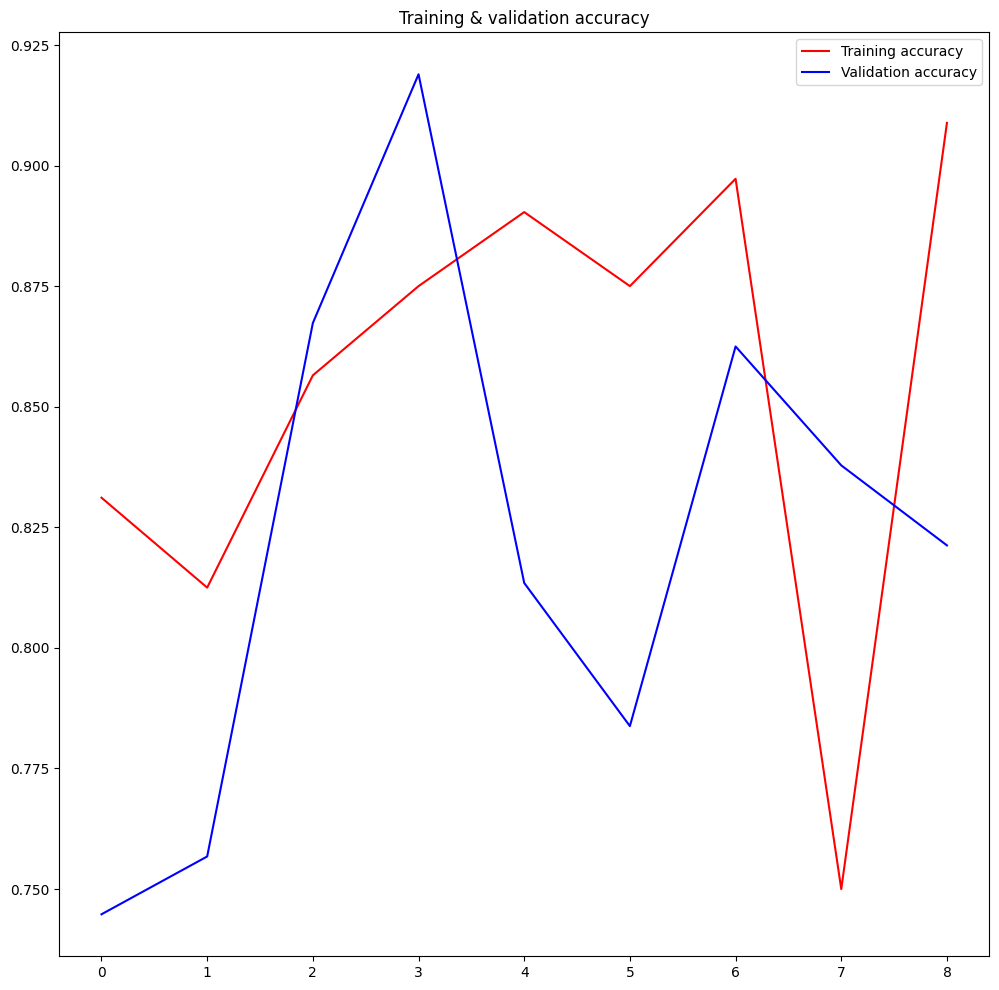

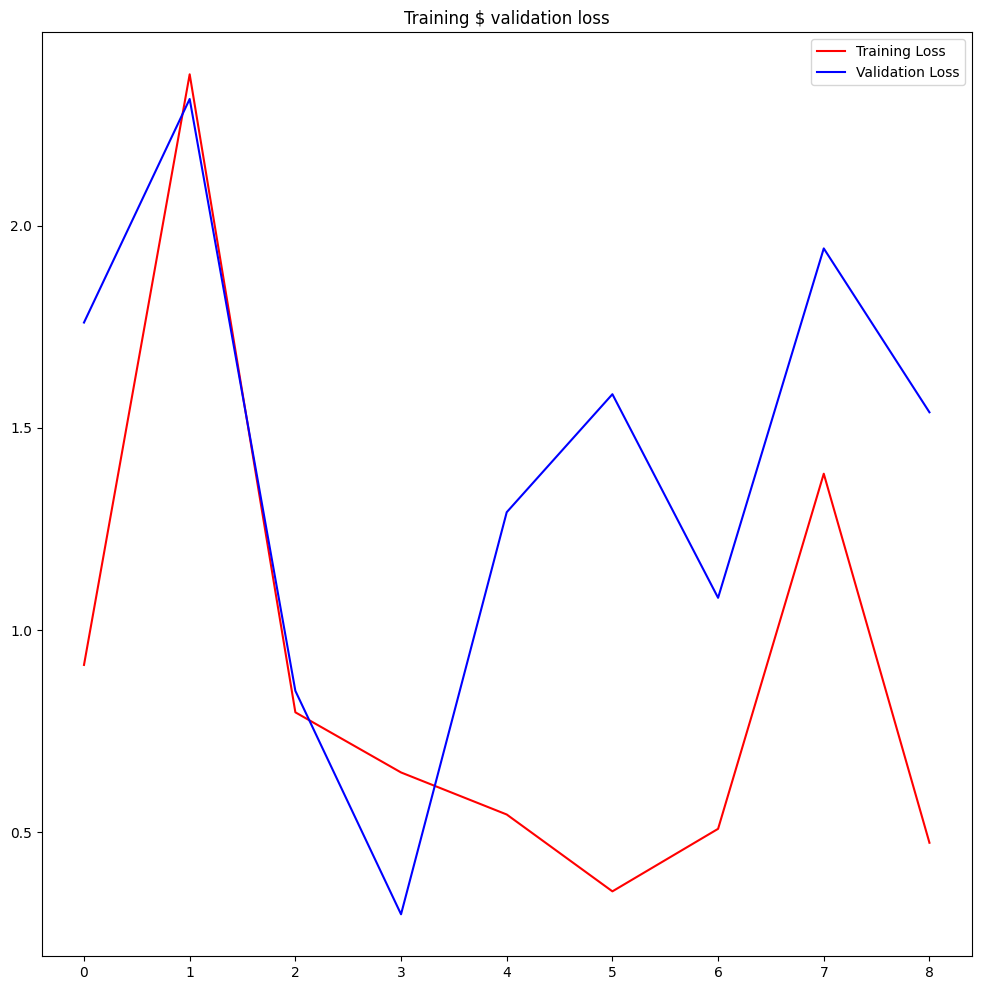

In [25]:
print("metrics of Inception V3")
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.figure(figsize=(12,12))

plt.plot(epochs, acc, 'r', label = 'Training accuracy')
plt.plot(epochs, val_acc, 'b', label = 'Validation accuracy')
plt.title('Training & validation accuracy')
plt.legend()

plt.figure(figsize = (12,12))

plt.plot(epochs, loss, 'r', label = 'Training Loss')
plt.plot(epochs, val_loss, 'b', label = 'Validation Loss')
plt.title('Training $ validation loss')
plt.legend()


# Evaluating Test Data

In [26]:
model.evaluate(test_generator)

171/171 ━━━━━━━━━━━━━━━━━━━━ 165s 966ms/step - accuracy: 0.8944 - auc: 0.9621 - loss: 0.6996 - precision: 0.8954 - recall: 0.8941


[0.7318422198295593,
 0.8909722566604614,
 0.9615234136581421,
 0.8920652270317078,
 0.8905149698257446]

# Classification Report

In [27]:
test_steps_per_epoch = np.math.ceil(test_generator.samples / test_generator.batch_size)

predictions = model.predict(test_generator, steps = test_steps_per_epoch)

predicted_classes = np.argmax(predictions, axis=1)

<ipython-input-27-67ac5c6a3380>:1: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  test_steps_per_epoch = np.math.ceil(test_generator.samples / test_generator.batch_size)


171/171 ━━━━━━━━━━━━━━━━━━━━ 53s 283ms/step


In [28]:
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

In [29]:
report = sklearn.metrics.classification_report(true_classes, predicted_classes, target_names = class_labels)
print(report) 

              precision    recall  f1-score   support

         CNV       0.91      0.92      0.92      3746
         DME       0.82      0.76      0.79      1161
      DRUSEN       0.60      0.61      0.61       887
      NORMAL       0.94      0.95      0.94      5139

    accuracy                           0.89     10933
   macro avg       0.82      0.81      0.81     10933
weighted avg       0.89      0.89      0.89     10933



# Confusion Matrix

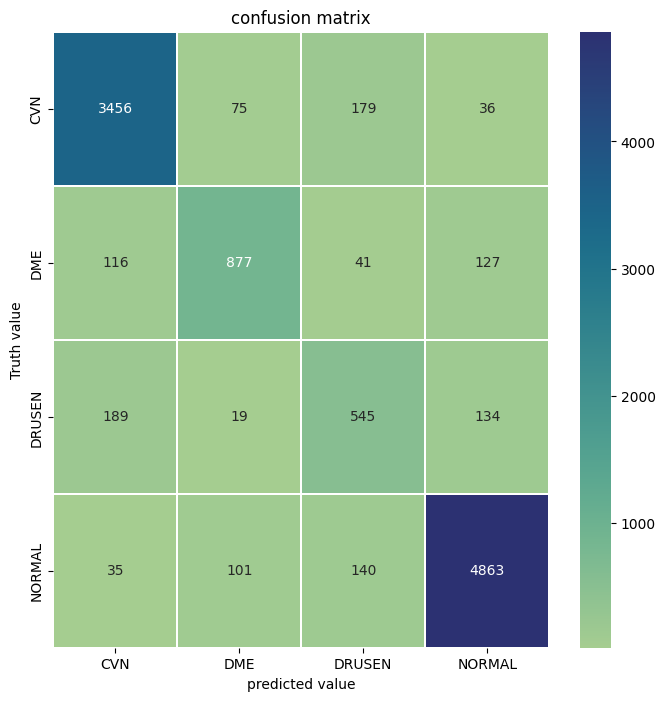

[[3456   75  179   36]
 [ 116  877   41  127]
 [ 189   19  545  134]
 [  35  101  140 4863]]


In [30]:
X_Label = ['CVN','DME','DRUSEN','NORMAL']
Y_Label = ['CVN','DME','DRUSEN','NORMAL']

cm = sklearn.metrics.confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8,8))
sns.heatmap(cm, fmt='.0f', cmap="crest", annot=True, linewidths=0.2, xticklabels=X_Label, yticklabels=Y_Label)
plt.title('confusion matrix')
plt.xlabel('predicted value')
plt.ylabel('Truth value')
plt.show()
print(sklearn.metrics.confusion_matrix(true_classes, predicted_classes))